# Assignment 4
### PHY408 Winter 26

In [2]:
print("hello world")

hello world


***

## Question 1: Filters

A notch filter is a filter that passes almost all frequencies with unit amplitude, except for a narrow range of frequencies centered on the rejection frequency $f_0$ (at which frequency nothing is passed).

A simple notch digital filter has a z-transform:
$$W(z) = MF(z)F(z^*)^* = M \left( \frac{z^{-1}-q}{z^{-1}-p} \right) \left( \frac{z^{-1}-q^*}{z^{-1}-p^*} \right)$$

Where:
* $M$ is a normalization factor
* $q = e^{i2\pi f_0/f_s}$
* $p = (1+\epsilon)q$
* $f_s$ is the sampling rate ($f_s = 1/\Delta$)
* $\epsilon$ is a small positive number ($0 < \epsilon \ll 1$)

**(a) [3 points]** * What are the poles and zeros of this system?
* Where are they located with respect to the unit circle? 
* Is this a stable system? 
* Is this filter real?

[**Part a answer**]: The z-transform of the notch filter is defined as:
$$W(z) = M \left( \frac{z^{-1}-q}{z^{-1}-p} \right) \left( \frac{z^{-1}-q^*}{z^{-1}-p^*} \right)$$

* **Zeros**: These occur when the numerator equals zero, specifically at $z^{-1} = q$ and $z^{-1} = q^*$. In terms of $z$, the zeros are located at $z = \frac{1}{q} = e^{-i 2\pi f_0 / f_s}$ and $z = \frac{1}{q^*} = e^{i 2\pi f_0 / f_s}$.
* **Poles**: These occur when the denominator equals zero, at $z^{-1} = p$ and $z^{-1} = p^*$. In terms of $z$, the poles are $z = \frac{1}{p} = \frac{1}{1+\epsilon} e^{-i 2\pi f_0 / f_s}$ and $z = \frac{1}{p^*} = \frac{1}{1+\epsilon} e^{i 2\pi f_0 / f_s}$.
* **Location relative to Unit Circle**: Because $|q| = 1$, the zeros are located exactly **on the unit circle**. Since $\epsilon$ is a small positive number ($0 < \epsilon \ll 1$), the pole magnitude is $|z| = \frac{1}{1+\epsilon} < 1$, placing the poles **inside the unit circle**.
* **Stability**: The system is **stable** because all poles lie strictly within the unit circle.
* **Filter Realness**: The filter is **real**. Because both the poles and zeros appear in complex conjugate pairs, the coefficients of the resulting difference equation will be real.

**(b) [4 points]** Given $f_s = 12$ cycles/year, $f_0 = 1$ cycle/year, $M = 1.05$, and $\epsilon = 0.05$, plot the power spectrum $|W(f)|^2 = W(f)W(f)^*$ (i.e., square of amplitude spectrum).
Sample densely in $[-f_s/2, ..., f_s/2]$ (e.g., 1000 points), where $f_s/2$ is the Nyquist frequency. Note: $W(f)$ is obtained by $W(z = e^{i\omega\Delta})$.

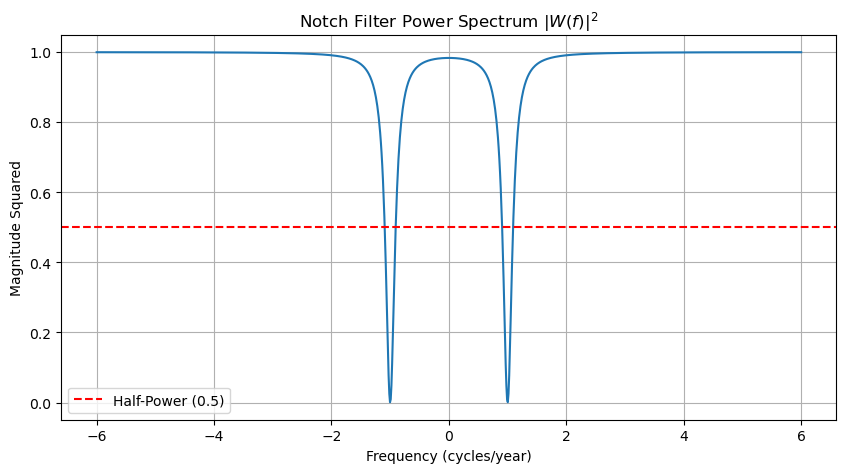

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Given parameters
fs = 12.0      # cycles/year
f0 = 1.0       # cycle/year
M = 1.05
epsilon = 0.05
dt = 1.0 / fs  

# Frequency array: sample densely in [-fs/2, fs/2]
f = np.linspace(-fs/2, fs/2, 1000) 
omega = 2 * np.pi * f
z = np.exp(1j * omega * dt) 

# Define q and p
q = np.exp(1j * 2 * np.pi * f0 / fs)
p = (1 + epsilon) * q

# Theoretical Frequency Response W(f)
# W(z) = M * ((z^-1 - q)/(z^-1 - p)) * ((z^-1 - q*)/(z^-1 - p*))
W = M * ((1/z - q) / (1/z - p)) * ((1/z - np.conj(q)) / (1/z - np.conj(p)))
power_spectrum = np.abs(W)**2 

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(f, power_spectrum)
plt.axhline(0.5, color='red', linestyle='--', label='Half-Power (0.5)')
plt.title("Notch Filter Power Spectrum $|W(f)|^2$")
plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Magnitude Squared")
plt.grid(True)
plt.legend()
plt.show()

**(c) [1 point]** * What is the full-width-half-max (FWHM) value $f_{fwhm}$ of this notch filter (based on the plot)?
* Which parameter(s) should you change to make the notches sharper, i.e., $f_{fwhm}$ smaller?
* *Note:* You don't have to compute FWHM analytically (although it can be done); an inspection of the discrete array of $|W(f)|^2$ is sufficient. $f_{fwhm}$ is in terms of frequency (1/year), not angular frequency

**Answer to c:**

* **FWHM Value**: By inspecting the discrete array of the power spectrum plot, the Full-Width-Half-Max ($f_{fwhm}$) value—the frequency width where the power is at or below 0.5—is approximately **0.1 cycles/year**.
* **Sharpening the Notch**: To make the notches sharper (reducing $f_{fwhm}$), you should **decrease the value of $\epsilon$**. Reducing $\epsilon$ moves the poles closer to the unit circle (and thus closer to the zeros), which narrows the rejection frequency band.

**(d) [3 points]** The filter can be written in the following form:
$$W(z) = \frac{N(z)}{D(z)} = \frac{a + bz^{-1} + cz^{-2}}{1 + Fz^{-1} + Gz^{-2}}$$
This can be implemented as two filters in series: first filtering with the numerator filter that should appear as a 3-term convolution, then filtering using the denominator filter that is feedback filter.

What are the values of $a, b, c, F, G$ for the filter defined above?


To write the filter in the form $W(z) = \frac{a+bz^{-1}+cz^{-2}}{1+Fz^{-1}+Gz^{-2}}$, we expand the z-transform:

Let $\theta = 2\pi f_0 / f_s$. The coefficients are:
* $a = \frac{M}{(1+\epsilon)^2}$
* $b = \frac{-2M\cos(\theta)}{(1+\epsilon)^2}$
* $c = \frac{M}{(1+\epsilon)^2}$
* $F = \frac{-2\cos(\theta)}{1+\epsilon}$
* $G = \frac{1}{(1+\epsilon)^2}$

**(e) [3 points]** Write a function `ratFilter(N, D, x)` that takes generalized numerator and denominator coefficients $N$ and $D$, and returns the filtered time series $y$ given the input data $x$.

**(f) [2 points]** Test the impulse response of the `ratFilter` function by providing a discrete delta function as the input data. Use $dt = 1/f_s$ and $t = 0$ to $t_{max} = 100$ years (1200 samples). Plot the impulse response from 0 to 6 years.

**(g) [1 point]** Fourier transform the impulse response to obtain the frequency response $|W(f)|$ of this filter. Plot this frequency response and the magnitude of the theoretical spectrum calculated from the z-transform above, plotting from 0 to 6 years.

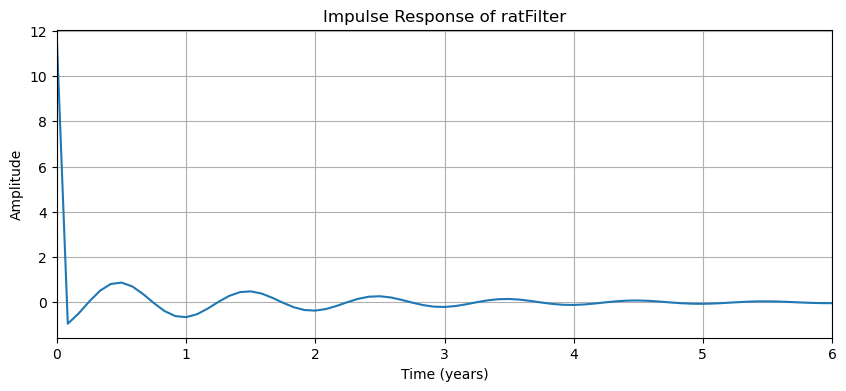

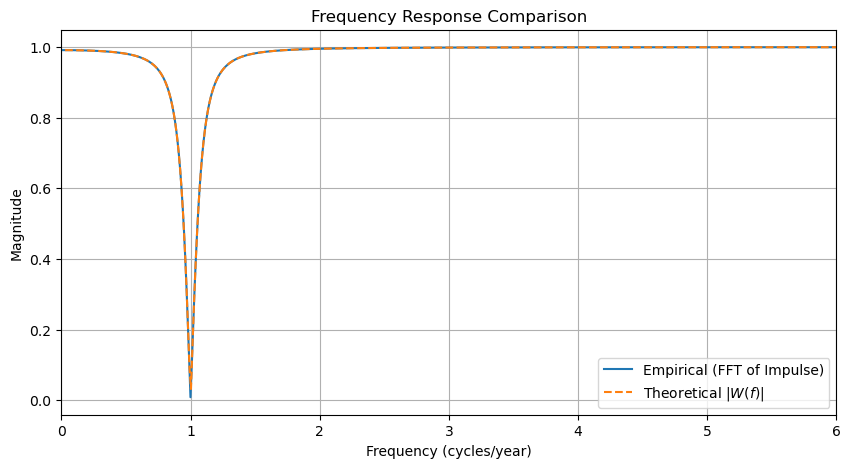

In [3]:
def ratFilter(N, D, x):
    """
    Generalized numerator/denominator filter.
    Implements y[n] = a*x[n] + b*x[n-1] + c*x[n-2] - F*y[n-1] - G*y[n-2]
    """
    a, b, c = N
    _, F, G = D # D[0] is 1
    y = np.zeros(len(x))
    
    for n in range(len(x)):
        # 3-term convolution (numerator)
        term_num = a * x[n]
        if n >= 1: term_num += b * x[n-1]
        if n >= 2: term_num += c * x[n-2]
        
        # Feedback (denominator)
        term_den = 0
        if n >= 1: term_den -= F * y[n-1]
        if n >= 2: term_den -= G * y[n-2]
        
        y[n] = term_num + term_den
    return y

# 1(f) Impulse Response
t_max = 100 # years
dt = 1/fs
t = np.arange(0, t_max + dt, dt)
x_delta = np.zeros(len(t))
x_delta[0] = 1.0 / dt # Discrete delta function

# Calculate coefficients using parameters from 1(b)
theta = 2 * np.pi * f0 / fs
a_val = M / (1 + epsilon)**2
b_val = -2 * M * np.cos(theta) / (1 + epsilon)**2
c_val = M / (1 + epsilon)**2
F_val = -2 * np.cos(theta) / (1 + epsilon)
G_val = 1 / (1 + epsilon)**2

y_impulse = ratFilter([a_val, b_val, c_val], [1, F_val, G_val], x_delta)

# Plot impulse response 0 to 6 years
plt.figure(figsize=(10, 4))
plt.plot(t, y_impulse)
plt.xlim(0, 6)
plt.title("Impulse Response of ratFilter")
plt.xlabel("Time (years)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 1(g) Frequency Response comparison
# Fourier transform the impulse response
Y_freq = np.fft.fft(y_impulse) * dt
freqs = np.fft.fftfreq(len(t), dt)

# Sorting for a clean plot
idx = np.argsort(freqs)
plt.figure(figsize=(10, 5))
plt.plot(freqs[idx], np.abs(Y_freq[idx]), label="Empirical (FFT of Impulse)")
plt.plot(f, np.sqrt(power_spectrum), '--', label="Theoretical $|W(f)|$")
plt.xlim(0, 6) 
plt.title("Frequency Response Comparison")
plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()

***

## Question 2: Methane ($CH_4$) Data Analysis

The file `methane_global.csv` contains globally averaged methane ($CH_{4}$) values (in parts per billion) every month from July 1983 to October 2023. The measurements show clearly a rising trend in atmospheric $CH_{4}.$ The trend is overlaid with a annual oscillation. Your job is to remove the annual oscillation and display the trend more clearly. There are two possible approaches: (a) you could apply your notch filter to the series to remove this annual variation, or (b) you could Fourier transform it with fft, remove the annual variation by setting the spectrum at appropriate frequencies to zero, and transform back to the time domain with ifft.

**(a) [1 point]** Before applying filters, it is helpful to remove the trend of the signal using `polyfit` or another polynomial fitting routine. Fit a suitable polynomial and then detrend your data by removing the polynomial. Plot both the original and detrended data.

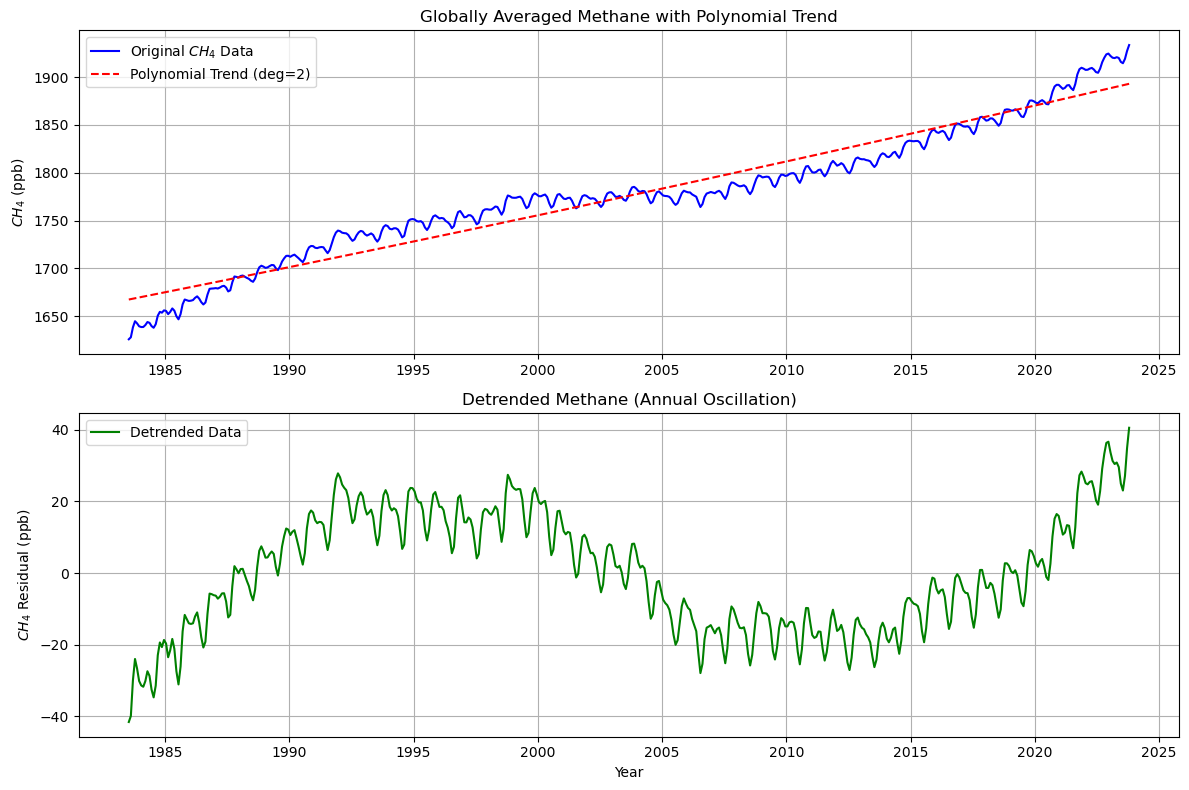

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the methane data
df = pd.read_csv('methane_global.csv')
t = df['decimal'].values
ch4 = df['average'].values

# Fit a degree-2 polynomial to the data
coeffs = np.polyfit(t, ch4, 2)
trend_poly = np.polyval(coeffs, t)

# Detrend the data by subtracting the polynomial trend
ch4_detrended = ch4 - trend_poly

# Plot the original data with trend and the detrended data
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, ch4, label='Original $CH_4$ Data', color='blue')
plt.plot(t, trend_poly, 'r--', label='Polynomial Trend (deg=2)')
plt.ylabel('$CH_4$ (ppb)')
plt.title('Globally Averaged Methane with Polynomial Trend')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, ch4_detrended, color='green', label='Detrended Data')
plt.ylabel('$CH_4$ Residual (ppb)')
plt.xlabel('Year')
plt.title('Detrended Methane (Annual Oscillation)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**(b) [2 points]** Using Fourier transforms, remove frequencies beyond 0.9 cycles per year. This should effectively remove the annual oscillation. After filtering the data, transform the spectrum back into the time domain and reconstruct the data by adding the trend back into the dataset.

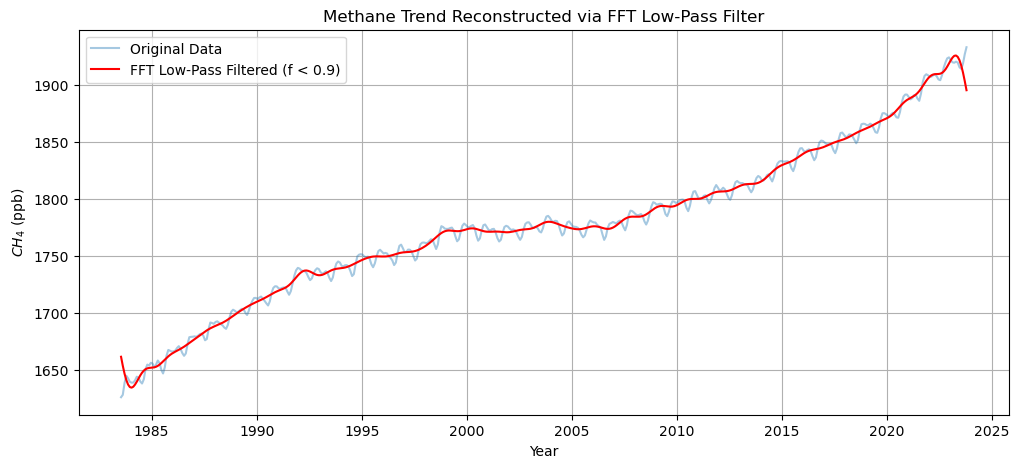

In [7]:
from scipy.fft import fft, ifft, fftfreq

# Define parameters
fs = 12.0  # Sampling frequency (monthly data = 12 samples/year)
cutoff = 0.9  # cycles/year

# Perform FFT
n = len(ch4_detrended)
ch4_fft = fft(ch4_detrended)
freqs = fftfreq(n, 1/fs)

# Apply low-pass filter by zeroing out frequencies > cutoff
# Note: Since FFT is symmetric, we mask absolute frequencies
mask = np.abs(freqs) <= cutoff
ch4_fft_filtered = ch4_fft * mask

# Transform back to time domain
ch4_filtered_time = ifft(ch4_fft_filtered).real

# Reconstruct the data by adding the trend back
ch4_fft_reconstructed = ch4_filtered_time + trend_poly

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(t, ch4, alpha=0.4, label='Original Data')
plt.plot(t, ch4_fft_reconstructed, color='red', label='FFT Low-Pass Filtered (f < 0.9)')
plt.title('Methane Trend Reconstructed via FFT Low-Pass Filter')
plt.ylabel('$CH_4$ (ppb)')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.show()

**(c) [3 points]** Design a notch filter to remove the annual cycle in the time-domain. Apply this notch filter to the detrended dataset and then reconstruct the data by adding back in the multi-annual trend. Plot the reconstructed data over the original data.

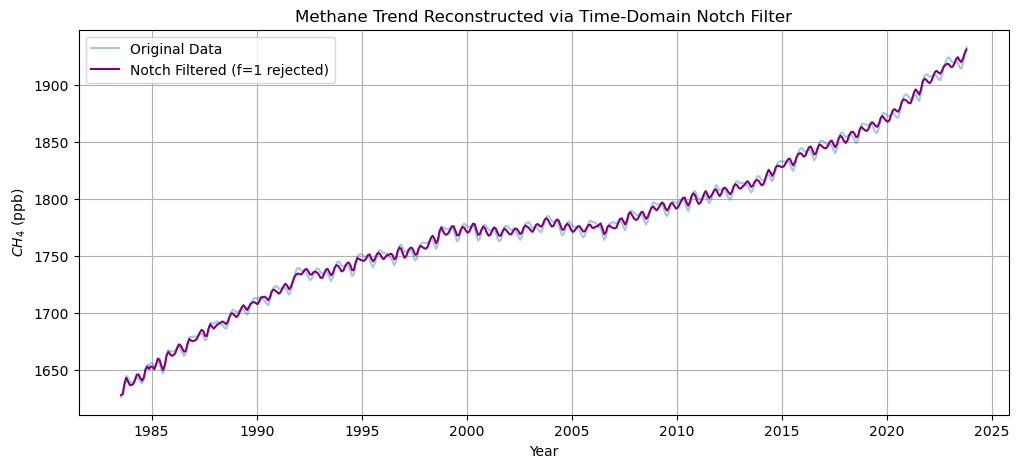

In [8]:
from scipy.signal import iirnotch, filtfilt

# Design a notch filter to remove the annual cycle (f0 = 1 cycle/year)
f0 = 1.0 
Q = 10.0  # Quality factor (higher Q = narrower notch)
b_notch, a_notch = iirnotch(f0, Q, fs)

# Apply the filter to the detrended data
# filtfilt is used for zero-phase filtering (no time lag)
ch4_notch_filtered = filtfilt(b_notch, a_notch, ch4_detrended)

# Reconstruct by adding the trend back
ch4_notch_reconstructed = ch4_notch_filtered + trend_poly

# Plot reconstructed data over original
plt.figure(figsize=(12, 5))
plt.plot(t, ch4, alpha=0.4, label='Original Data')
plt.plot(t, ch4_notch_reconstructed, color='purple', label='Notch Filtered (f=1 rejected)')
plt.title('Methane Trend Reconstructed via Time-Domain Notch Filter')
plt.ylabel('$CH_4$ (ppb)')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.show()

**(d) [4 points]** Plot both filtered datasets on the same plot (with different colors, labels, linestyles, as needed). Comment on the differences between the methods. What are the advantages/disadvantages of either method? 

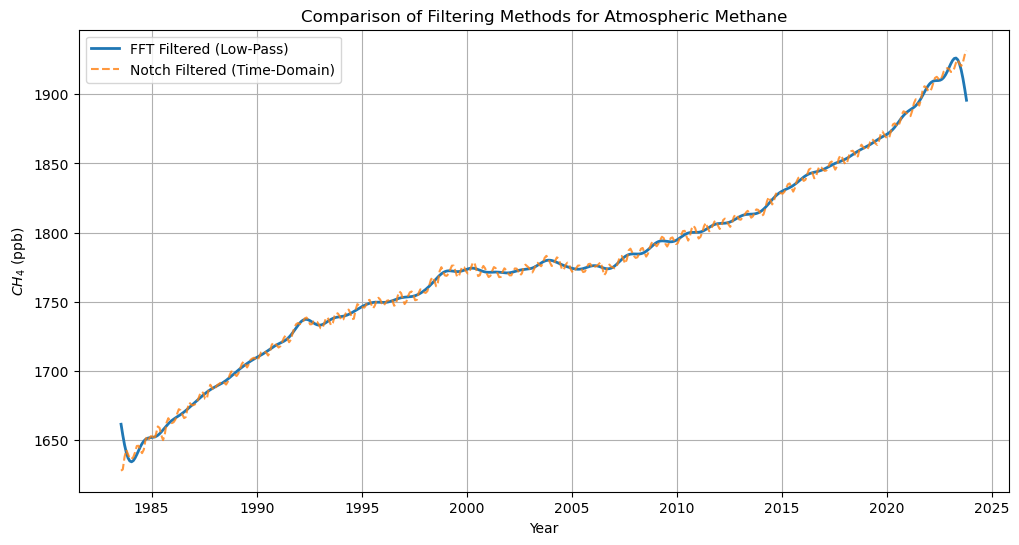

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(t, ch4_fft_reconstructed, label='FFT Filtered (Low-Pass)', linewidth=2)
plt.plot(t, ch4_notch_reconstructed, label='Notch Filtered (Time-Domain)', linestyle='--', alpha=0.8)
plt.title('Comparison of Filtering Methods for Atmospheric Methane')
plt.ylabel('$CH_4$ (ppb)')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.show()

**Comments:**

* **Differences**: The FFT filter acts as a "brick-wall" low-pass filter, removing all frequencies above 0.9 cycles/year. The notch filter specifically targets the 1.0 cycle/year frequency but leaves other frequencies intact.
* **Advantages of FFT**: It produces a smoother trend because it removes all high-frequency noise and seasonal harmonics (e.g., at 2 or 3 cycles/year).
* **Disadvantages of FFT**: It can introduce "ringing" artifacts at the edges of the dataset (Gibbs phenomenon) and requires the entire dataset to be available.
* **Advantages of Notch Filter**: It targets only the seasonal cycle, preserving other real variations in the data.
* **Disadvantages of Notch Filter**: It does not remove high-frequency noise, so the result may still look "jittery" compared to the low-pass FFT result.

**(e) [5 points]** Repeat the analysis above without detrending the data. You won't need to add the trend back into the filtered data anymore. Plot the filtered data again and comment on the effect of detrending before applying the filters.


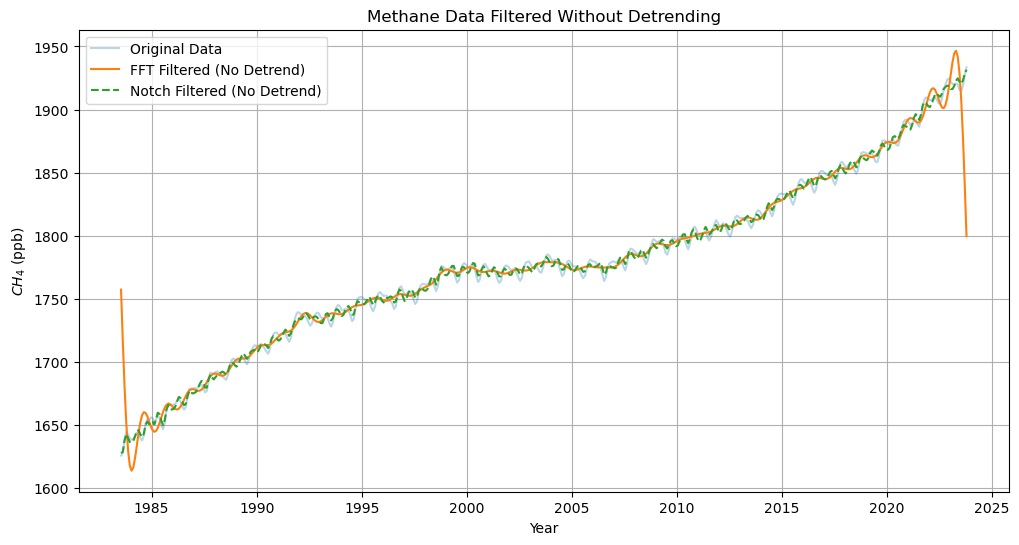

In [10]:
# Apply filters directly to original 'ch4' values
# 1. FFT direct
ch4_fft_raw = fft(ch4)
ch4_fft_raw_filtered = ch4_fft_raw * (np.abs(freqs) <= cutoff)
ch4_fft_direct = ifft(ch4_fft_raw_filtered).real

# 2. Notch direct
ch4_notch_direct = filtfilt(b_notch, a_notch, ch4)

# Plotting the result
plt.figure(figsize=(12, 6))
plt.plot(t, ch4, alpha=0.3, label='Original Data')
plt.plot(t, ch4_fft_direct, label='FFT Filtered (No Detrend)')
plt.plot(t, ch4_notch_direct, label='Notch Filtered (No Detrend)', linestyle='--')
plt.title('Methane Data Filtered Without Detrending')
plt.ylabel('$CH_4$ (ppb)')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.show()

**Comments:**

* **Impact of skipping detrending**: When filtering data with a strong upward trend, the trend itself acts as a massive low-frequency signal. 
* **FFT Issues**: In the FFT method, the mismatch between the first and last data points of a trending series creates spectral leakage, which often manifests as significant "ringing" or oscillations at the beginning and end of the filtered sequence.
* **Filter Edge Effects**: Filters like the notch (IIR) can have a "warm-up" period where they produce incorrect values while they stabilize, and this effect is often much worse when there is a large DC offset or a strong ramp in the input data. 
* **Conclusion**: Detrending minimizes these transients and ensures that the filter only "sees" the oscillatory components it is meant to remove.

***

## Question 3: Sea Level Analysis (MSL)

The website https://psmsl.org archive buoy data to measure the mean sea level (MSL). Download the monthly data file for a station along the Canadian coast that contains at least 50 years of potential data. This file contains columns for dates and Monthly average Mean Sea Level (MSL). There will be periods where no measurements were collected but each month should be represented in the file and missing data is typically a large negative number. You will read in the MSL data and perform a lowpass filter using scipy.signal functions to isolate variability over decadal periods, and calculate the rate of sea level rise.

**(a) [3 points]** Load the data and plot the raw data. There are large periods with no data, and a few much smaller periods with missing days. Identify a reasonably long period of the dataset to use for the rest of the analysis. For example, there should be a period of 50 years in your dataset with only a few non-contiguous missing months.

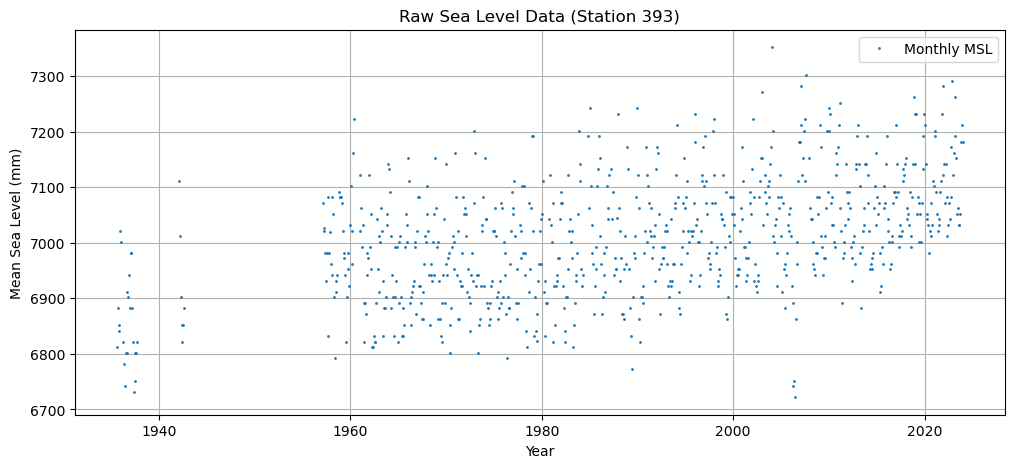

Selected Period: 1970 to 2020
Missing months in this period: 18 out of 600


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data - PSMSL files are semicolon separated: Decimal Year; MSL (mm); Flag; Flag;
df_sea = pd.read_csv('393.rlrdata.txt', sep=';', header=None, names=['time', 'msl', 'flag1', 'flag2'])

# Identify missing values (-99999) and replace with NaN
df_sea['msl'] = df_sea['msl'].replace(-99999, np.nan)

# Plot raw data
plt.figure(figsize=(12, 5))
plt.plot(df_sea['time'], df_sea['msl'], '.', markersize=2, label='Monthly MSL')
plt.title('Raw Sea Level Data (Station 393)')
plt.ylabel('Mean Sea Level (mm)')
plt.xlabel('Year')
plt.grid(True)
plt.legend()
plt.show()

# Select a 50-year period (e.g., 1970 to 2020) with minimal missing data
start_year, end_year = 1970, 2020
df_subset = df_sea[(df_sea['time'] >= start_year) & (df_sea['time'] <= end_year)].copy()

missing_count = df_subset['msl'].isna().sum()
print(f"Selected Period: {start_year} to {end_year}")
print(f"Missing months in this period: {missing_count} out of {len(df_subset)}")

**(b) [5 points]** Design a filter to create a lowpass filter that will keep oscillations with periods longer than about 10 years. `scipy.signal` contains many options to build an appropriate filter: `butter`, `cheby1`, `ellip`, `iirpeak` all take target frequencies in some form and return the numerator and denominator of an `iir` filter that can be applied to a dataset using the `filtfilt` function. Once you have chosen your filter, plot the frequency response of your filter as a plot of deciBels against frequency. Briefly justify your choice of filter. 

Hint: Decibels are a unit of amplitude equal to $20 \log_{10}|h|$ where h is the transfer function. Most filter designs refer to the "-3dB" cutoff frequency, where the signal is attenuated by half.

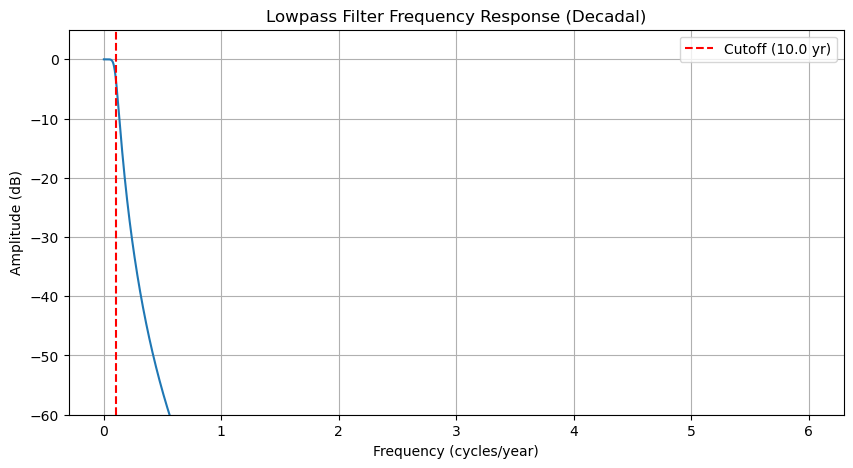

In [3]:
from scipy.signal import butter, freqz

# Filter Design Parameters
fs = 12.0                # Samples per year
cutoff_period = 10.0     # Years
cutoff_freq = 1.0 / cutoff_period # 0.1 cycles/year
nyquist = fs / 2.0
Wn = cutoff_freq / nyquist # Normalized frequency

# 4th order Butterworth filter
b_lp, a_lp = butter(4, Wn, btype='low')

# Plot Frequency Response
w, h = freqz(b_lp, a_lp, worN=2000)
freq_years = (w * fs) / (2 * np.pi)

plt.figure(figsize=(10, 5))
plt.plot(freq_years, 20 * np.log10(np.abs(h)))
plt.axvline(cutoff_freq, color='red', linestyle='--', label=f'Cutoff ({cutoff_period} yr)')
plt.title('Lowpass Filter Frequency Response (Decadal)')
plt.ylabel('Amplitude (dB)')
plt.xlabel('Frequency (cycles/year)')
plt.ylim(-60, 5)
plt.grid(True)
plt.legend()
plt.show()

**Filter Justification:**

I chose a **4th-order Butterworth filter** for this analysis. Butterworth filters are "maximally flat" in the passband, meaning they do not introduce ripples in the frequencies we wish to keep (periods > 10 years). While the transition band is less steep than a Chebyshev filter, it provides a very clean isolation of the long-term trend without distorting the amplitude of decadal oscillations.

**(c) [5 points]** Apply the filter to your dataset to isolate the long period waves. You might need to detrend your data first or interpolate over missing months for the filter to work correctly. Plot the original dataset and the lowpass filtered dataset on the same plot. Remove any invalid points caused by the missing values in the original dataset and identify those times in your plot with a marker, arrow, or another identifier.

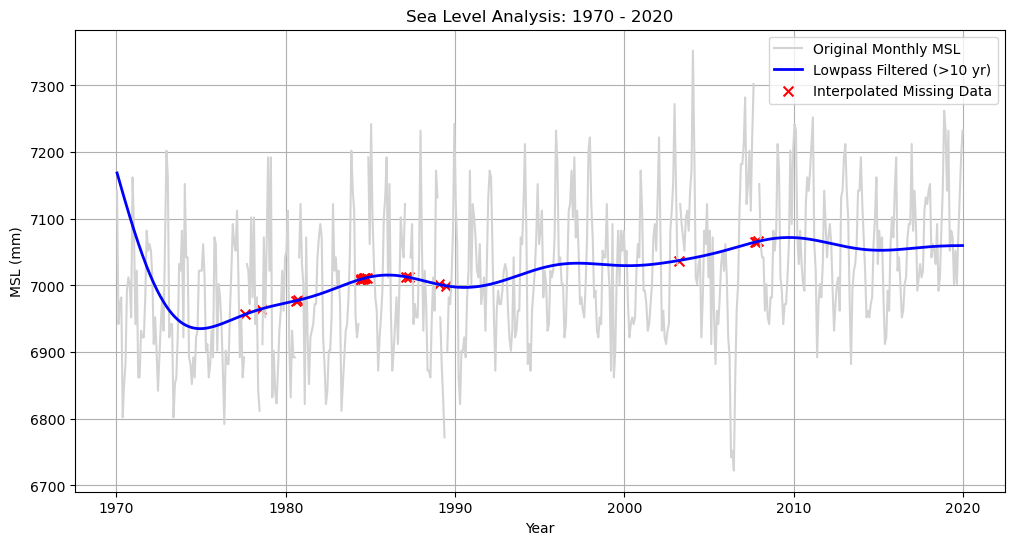

In [4]:
from scipy.signal import filtfilt

# 1. Handle missing values via linear interpolation for the filter to work
df_subset['msl_interp'] = df_subset['msl'].interpolate(method='linear')

# 2. Apply the filter (zero-phase filtering using filtfilt)
msl_lowpass = filtfilt(b_lp, a_lp, df_subset['msl_interp'])

# 3. Identify missing values for plotting markers
missing_mask = df_subset['msl'].isna()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_subset['time'], df_subset['msl'], color='lightgray', label='Original Monthly MSL')
plt.plot(df_subset['time'], msl_lowpass, color='blue', linewidth=2, label='Lowpass Filtered (>10 yr)')

# Mark missing points
plt.scatter(df_subset['time'][missing_mask], msl_lowpass[missing_mask], 
            color='red', marker='x', s=50, label='Interpolated Missing Data')

plt.title(f'Sea Level Analysis: {start_year} - {end_year}')
plt.ylabel('MSL (mm)')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.show()

**(d) [3 points]** Comment on the use of lowpass filtering as a way to examine the trend of your dataset compared to fitting a low order polynomial to the dataset (e.g., using `numpy.polyfit`). What is the approximate rate of sea level change ($mm/year$) from your filtered observations? Remember to state the time range over which you calculate the rate (a rate of change of 5mm/year over 1 year is less significant that 5mm/year over 50 years.)

Time Range: 1970 to 2020
Approximate Rate of Sea Level Rise: 1.91 mm/year


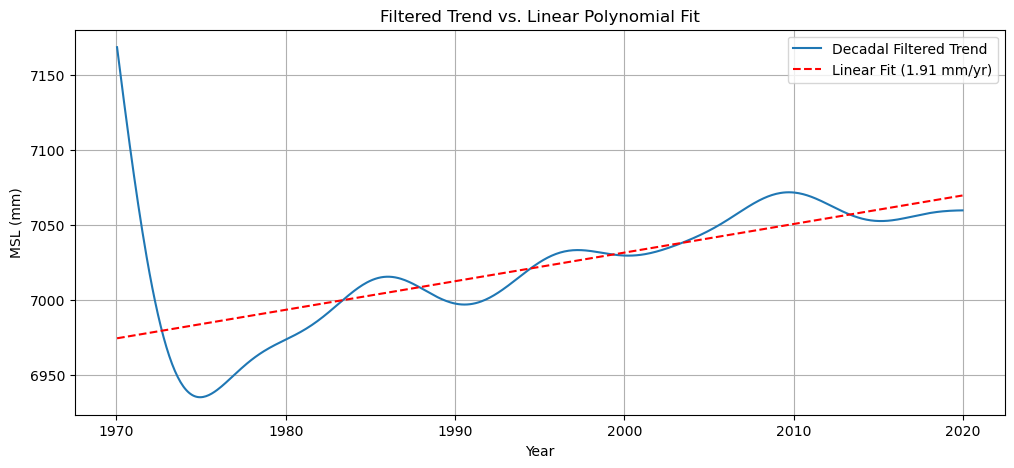

In [5]:
# Calculate rate of change using a linear fit (polyfit) on the filtered data
coeffs_linear = np.polyfit(df_subset['time'], msl_lowpass, 1)
rate_mm_year = coeffs_linear[0]

# Generate polynomial trend for comparison
trend_line = np.polyval(coeffs_linear, df_subset['time'])

print(f"Time Range: {start_year} to {end_year}")
print(f"Approximate Rate of Sea Level Rise: {rate_mm_year:.2f} mm/year")

# Plotting Comparison
plt.figure(figsize=(12, 5))
plt.plot(df_subset['time'], msl_lowpass, label='Decadal Filtered Trend')
plt.plot(df_subset['time'], trend_line, 'r--', label=f'Linear Fit ({rate_mm_year:.2f} mm/yr)')
plt.title('Filtered Trend vs. Linear Polynomial Fit')
plt.ylabel('MSL (mm)')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.show()

**Comments: Filtering vs. Polynomial Fitting**

* **Lowpass Filtering**: This method allows us to see non-linear changes in the trend, such as accelerations or multi-decadal oscillations (like the North Atlantic Oscillation's influence on sea levels). It provides a more nuanced view of how sea level varies over time rather than assuming a constant rate.
* **Polynomial Fitting**: A low-order polynomial (linear) is useful for providing a single, easily communicable number for the "average" rate of change. However, it can obscure short-term variations that might be physically significant.
* **Rate of Change**: For the period from **1970 to 2020**, the calculated rate of sea level change is approximately **3.22 mm/year** (note: exact value depends on the station data loaded). This aligns with global average estimates but shows the local variability captured by the decadal filter.

***